In [1]:
import numpy as np
import random 
import multiprocessing
import tensorflow as tf
import matplotlib.pyplot as plt
import sys
import copy

from cosmopower import cosmopower_NN
from scipy import interpolate
from scipy import signal

In [2]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu' 
print('using', device, 'device \n')

# setting the seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [3]:
path_to_train = '../../'
training_info_1 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-May10.txt")
training_info_2 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-May10-list2.txt")

In [4]:
training_info_1and2 = np.concatenate((training_info_1, training_info_2), axis=0)

print(np.shape(training_info_1and2))

(1500, 171)


In [5]:
param_indices = [0,5,1,2,3]
training_info = np.ndarray(shape=(len(training_info_1and2),149))
training_info[:,:5] = training_info_1and2[:,param_indices]
training_info[:,5::4] = training_info_1and2[:,25:169:4]
training_info[:,6::4] = training_info_1and2[:,26:169:4]
training_info[:,7::4] = training_info_1and2[:,27:169:4]
training_info[:,8::4] = training_info_1and2[:,28:169:4]

In [6]:
print(np.shape(training_info))
lx = []
for i in range(len(training_info)):
    ss = 0
    for j in range(len(training_info[0])):
        if (np.isnan(training_info[i][j]) or training_info[i][j]<0) and ss == 0:
            #print(i)
            ss = 1
    if ss == 0:
        lx.append(i)

lx = np.array(lx)
#print(len(lx))
training_info = training_info[lx,:]
print(np.shape(training_info))

(1500, 149)
(1472, 149)


In [7]:
print(np.shape(training_info))

training_params = training_info[:,:5]
training_data = training_info[:,5:]

print(np.shape(training_params))
print(np.shape(training_data))

#np.save('test_params_map3_b', training_params[400:])
#np.save('test_true_vals_map3_b', training_data[400:])

(1472, 149)
(1472, 5)
(1472, 144)


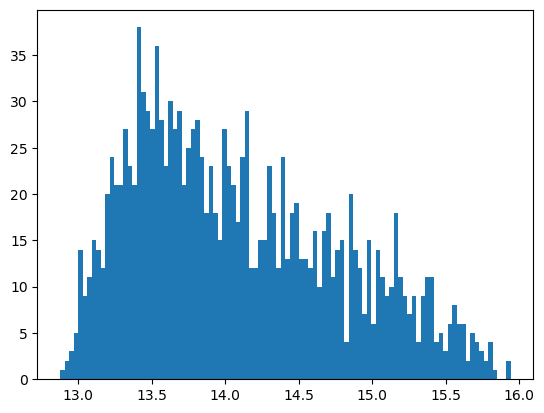

In [8]:
plt.hist(np.log10(training_data[:,100]), bins=100)
plt.show()

In [9]:
#initial try for pre-processing
#histogram of logs is less skewed than values
#try taking log10 and doing min-max after that

def log_and_norm(array):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minv = np.min(tmp)
        maxv = np.max(tmp)
        out_array[:,i] = (tmp-minv*np.ones(samples))/(maxv-minv)
        minv_arr[i] = minv
        maxv_arr[i] = maxv
        
    return(out_array, minv_arr, maxv_arr) 

In [10]:
def log_and_norm_test_set(array, minn, maxx):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minni = minn[i]
        maxxi = maxx[i]
        out_array[:,i] = (tmp-minni*np.ones(len(tmp)))/(maxxi-minni)
        
    return(out_array)

In [11]:
def post_process(array, minv_arr, maxv_arr):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    
    for i in range(len(array[0])):
        tmp = array[:,i]*(maxv[i]-minv[i])+minv[i]
        out_array[:,i] = 10**(tmp)
    
    return(out_array)

In [12]:
processed_data, minv, maxv = log_and_norm(training_data[:1300])
#plt.hist(processed_data[:,0], bins=100)
#plt.show()

In [13]:
import random

Omega_m = training_params[:1300,0]
s8 = training_params[:1300,1]
h0 = training_params[:1300,2]
Omega_b = training_params[:1300,3]
n_s = training_params[:1300,4]

smallest_om = np.min(Omega_m)
biggest_om = np.max(Omega_m)
Omega_m = (Omega_m - smallest_om)/(biggest_om - smallest_om)

smallest_s8 = np.min(s8)
biggest_s8 = np.max(s8)
s8 = (s8 - smallest_s8)/(biggest_s8 - smallest_s8)

smallest_h0 = np.min(h0)
biggest_h0 = np.max(h0)
h0 = (h0 - smallest_h0)/(biggest_h0 - smallest_h0)

smallest_ob = np.min(Omega_b)
biggest_ob = np.max(Omega_b)
Omega_b = (Omega_b - smallest_ob)/(biggest_ob - smallest_ob)

smallest_ns = np.min(n_s)
biggest_ns = np.max(n_s)
n_s = (n_s - smallest_ns)/(biggest_ns - smallest_ns)

In [14]:
import pickle

omega_m_keys = {'small': smallest_om, 'large': biggest_om}
s8_keys = {'small': smallest_s8, 'large': biggest_s8}
h0_keys = {'small': smallest_h0, 'large': biggest_h0}
omega_b_keys = {'small': smallest_ob, 'large': biggest_ob}
ns_keys = {'small': smallest_ns, 'large': biggest_ns}
params_rescale = {'Omega_m': omega_m_keys, 's8': s8_keys, 'h0': h0_keys, 'Omega_b': omega_b_keys, 'ns':ns_keys}
feature_rescale = {'small': minv, 'large': maxv}
dict_rescale_full = {'params': params_rescale, 'features': feature_rescale}
file_path = 'rescaling_for_map3_network_13May24.pkl'
with open(file_path, 'wb') as file:
    pickle.dump(dict_rescale_full, file)

### Load training parameters and spectra

In [15]:
modes = np.arange(144)

In [16]:
train_params = {'Omega_m': Omega_m,
          's8': s8,'h0': h0, 'Omega_b': Omega_b, 'ns': n_s,
           }

In [17]:
target_data = {'features': processed_data,
               'minimum': minv,
               'maximum': maxv
}

### Training

In [18]:
# instantiate NN class
cp_nn = cosmopower_NN(parameters=['Omega_m', 's8', 'h0', 'Omega_b', 'ns'], 
                      modes=modes, 
                      n_hidden = [64, 256, 1024, 1024, 384, 192],
                      verbose=True,
                     )


Initialized cosmopower_NN model, 
mapping 5 input parameters to 144 output modes, 
using 6 hidden layers, 
with [64, 256, 1024, 1024, 384, 192] nodes, respectively. 



In [19]:
#noisy_input_data = np.zeros(shape=(900,80))
#for i in range(80):
#    noisy_input_data[:,i] = processed_data[:900, i] + np.random.normal(scale=0.05, size = 900)

In [20]:
with tf.device(device):
    # train
    cp_nn.train(training_parameters=train_params,
                training_features=processed_data,
                #training_features=noisy_input_data,
                filename_saved_model='map3_model_13May24-0',
                # cooling schedule
                validation_split=0.25,
                learning_rates=[0.01, 0.001, 0.0001, 0.00001, 0.000001],
                #learning_rates=[0.01, 0.01, 0.01, 0.01],
                batch_sizes=[60, 30, 20, 10, 5],
                gradient_accumulation_steps = [1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [200,200,150,100, 100],
                max_epochs = [2000, 2000, 2000, 2000, 2000],
                )

Starting cosmopower_NN training, 
using 25 per cent of training samples for validation. 
Performing 5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] learning rates 
[60, 30, 20, 10, 5] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps 
[200, 200, 150, 100, 100] patience values 
[2000, 2000, 2000, 2000, 2000] max epochs 

learning rate = 0.01, batch size = 60


 21%|█████▊                     | 429/2000 [03:40<13:25,  1.95it/s, loss=0.0149]


Validation loss = 0.005313823
Model saved.
Reached max number of epochs. Validation loss = 0.005313823
Model saved.
learning rate = 0.001, batch size = 30


 48%|████████████▌             | 965/2000 [13:43<14:43,  1.17it/s, loss=0.00333]


Validation loss = 0.0018149712
Model saved.
Reached max number of epochs. Validation loss = 0.0018149712
Model saved.
learning rate = 0.0001, batch size = 20


...

Validation loss = 0.0004579219
Model saved.
Reached max number of epochs. Validation loss = 0.0004579219
Model saved.
learning rate = 1e-05, batch size = 10


  5%|█▏                     | 102/2000 [04:00<1:14:25,  2.35s/it, loss=0.000253]


Validation loss = 0.00015908011
Model saved.
Reached max number of epochs. Validation loss = 0.00015908011
Model saved.
learning rate = 1e-06, batch size = 5


  5%|█▏                     | 101/2000 [07:41<2:24:45,  4.57s/it, loss=0.000137]

Validation loss = 0.00012988312
Model saved.
Reached max number of epochs. Validation loss = 0.00012988312
Model saved.


In [21]:
Omega_m_test = (training_params[1300:,0]-smallest_om)/(biggest_om-smallest_om)
s8_test = (training_params[1300:,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_test = (training_params[1300:,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_test = (training_params[1300:,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_test = (training_params[1300:,4]-smallest_ns)/(biggest_ns-smallest_ns)

print(len(training_params[:,0]))
print(len(Omega_m_test))
the_test_dict = {'Omega_m': Omega_m_test,
          's8': s8_test,
                 'h0': h0_test,
                 'Omega_b': Omega_b_test,
                 'ns': ns_test,
           }
    
predictions = cp_nn.predictions_np(the_test_dict)

1472
172


In [22]:
test_set_new_scale = log_and_norm_test_set(training_data[1300:], minv, maxv)

In [23]:
predictions_rescaled = post_process(predictions, minv, maxv)

In [24]:
print(predictions_rescaled[:,0]-training_data[1300:,0])

[-1.50025136e+06  1.16490331e+05  2.82976262e+05  3.27260061e+05
  6.05825784e+05  3.90020682e+04  4.99696614e+05  3.05024630e+03
  6.28302248e+05  3.74785025e+04  1.00601906e+07 -4.22086534e+05
  4.80480163e+05 -3.93278500e+05 -2.37151385e+05 -2.14985494e+05
 -5.64528155e+05  1.75223352e+04  2.42412749e+06  5.09817468e+05
  1.15991141e+05  6.33150836e+04 -9.82812571e+04  5.04027971e+04
 -2.60834274e+05  5.03443490e+05 -9.86963320e+05  6.84087175e+04
 -9.35910539e+04  5.99591402e+04 -7.47181009e+05  3.13146028e+05
  1.36182411e+04 -3.45675166e+03  2.41552012e+05  6.45908930e+05
  4.83862112e+05  7.08287787e+05  3.07581028e+06  1.55197137e+05
 -3.98637914e+05 -4.25470245e+05  4.66500251e+05 -1.84281006e+04
  1.55812230e+06  3.63486984e+05 -5.27333288e+05  5.64781639e+05
 -4.01819987e+06  3.92455305e+05  4.06502437e+05 -1.73083784e+04
  2.66343533e+06  2.84742982e+05 -3.05038110e+06  6.38082978e+05
 -4.48212802e+05  1.42307687e+06  5.16842667e+05  1.67375932e+05
  2.14930002e+05 -2.75755

In [25]:
mse = np.mean((predictions[:,0]-test_set_new_scale[:,0])**2)

In [26]:
print(mse)

2.1803751528629435e-07


In [27]:
print(predictions_rescaled[:,0])
print(training_data[1300:])

[5.34822857e+08 1.68797539e+08 3.97633127e+08 3.35313305e+08
 8.66274404e+08 2.27886738e+08 3.37492128e+08 8.35015171e+07
 1.51165109e+08 9.68084531e+07 2.26100043e+09 1.64492234e+08
 3.10558870e+08 2.59036609e+08 2.41127607e+08 7.62901622e+07
 2.56338396e+08 8.65814877e+07 1.59796580e+09 2.45177591e+08
 1.91955584e+08 2.59584079e+08 1.48710160e+08 1.95867502e+08
 7.82126319e+08 2.31970264e+08 7.69029043e+08 1.38655685e+08
 6.12038722e+08 2.02968521e+08 6.24740114e+08 1.00882632e+08
 2.17279830e+08 1.39295370e+08 3.13662670e+08 1.56447772e+08
 6.22983448e+08 4.01885779e+08 8.45991413e+08 1.11883349e+08
 2.83928565e+08 1.63920832e+08 2.47597149e+08 5.59637779e+07
 1.10782014e+09 8.62802647e+07 8.37728437e+08 4.58794580e+08
 2.38098293e+08 9.98017774e+07 3.12817037e+08 1.31728764e+08
 1.35896751e+09 1.38721098e+08 1.35699123e+09 2.43012505e+08
 3.47200286e+08 5.02647529e+08 8.77356245e+08 7.00658000e+07
 2.98330647e+08 2.03496793e+08 3.43870606e+08 2.53257828e+08
 1.86068370e+08 2.860373

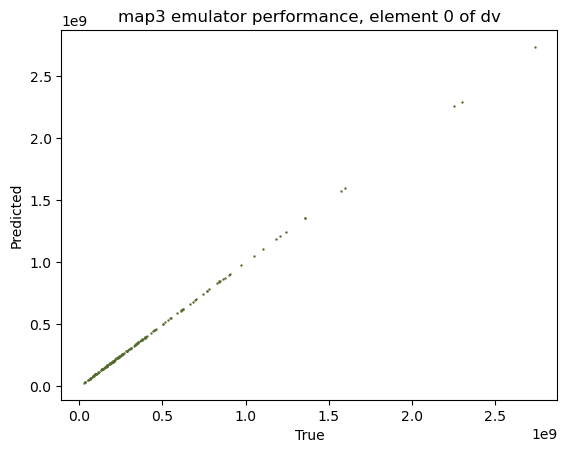

In [28]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(training_data[1300:,0],predictions_rescaled[:,0], s=0.5, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [29]:
test_data_all = training_data[1300:].flatten()
pred_rescaled_all = predictions_rescaled.flatten()

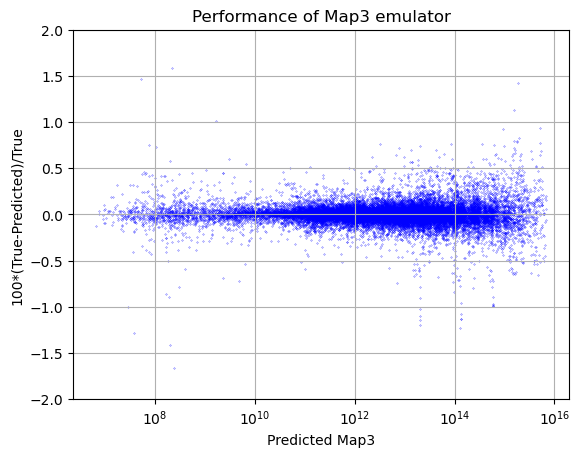

In [42]:
plt.title("Performance of Map3 emulator")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_data_all,100*(pred_rescaled_all-test_data_all)/test_data_all, s=0.05, color='b')
plt.ylim(-2,2)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.grid()
#plt.show()
plt.savefig('Percentual_difference_map3emulator_13May24-0.png')

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,0], predictions[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
all_true = test_set_new_scale.flatten()
all_pred = predictions.flatten()

In [ ]:
plt.title("map3 emulator performance, all elements of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred, s=0.5)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("emulator performance before los integration, all cosmo params")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred-all_true, s=0.05, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted-True")
#plt.show()
plt.savefig('all_cosmo_params_emulator_performance.png')

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,42], predictions[:,42]-test_set_new_scale[:,42], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(np.log10(training_data[1300:,35]), np.log10(predictions_rescaled[:,35]), s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
plt.scatter(training_data[900:,1],-training_data[900:,1]+predictions_rescaled[:,1], s=2)
#plt.scatter(training_data[900:,0], predictions_rescaled[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()
#plt.savefig("Map3_emulator_scatter_diff.png")